# ViT Model Training Specified for Google Colab:

**This is a specific version of the "ViT_Training" notebook. While it may not run properly here in VS, it should run error-free when imported to Google Colab. Below is an image of the exact files you need for the notebook to import the data: "qr_images.zip" and "qr_labels.csv"**

<img src="colab_setup.png" width=400>

## Imports and Login:

In [1]:
!pip -q install datasets
!pip -q install evaluate
!pip -q install 'accelerate>=0.26.0'
!pip -q install grad-cam



In [2]:
import io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from huggingface_hub import notebook_login
from datasets import Dataset
from transformers import AutoImageProcessor, ViTForImageClassification
from datasets import Image as HFImage
from PIL import Image

from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
import evaluate

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

import zipfile
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
notebook_login()

## Loading and Preparing Dataset:

In [ ]:
# Defining paths
qr_labels_path = "/content/qr_labels.csv"
zip_file_path = "/content/qr_images.zip"
extracted_dir_path = "/content/qr_images_extracted"

In [ ]:
# Creating the extraction directory if it doesn't exist
os.makedirs(extracted_dir_path, exist_ok=True)

# Unzipping the file
with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
    zip_ref.extractall(extracted_dir_path)

In [ ]:
# Defining path to images after file has been unzipped
qr_images_path = "/content/qr_images_extracted/qr_images"

In [ ]:
def get_all_qr_paths(filepath: str) -> list:
    """
    Takes in the path to the directory holding all QR images, and return the image file paths as a list

    Args:
        filepath: The path to the directory holding the QR images

    Returns:
        list: A list holding full paths to QR image files
    """

    # Defining sorting helper function
    def extract_number(filename: str) -> int:
        """
        Extracts the ID or number corresponding to the QR image

        Args:
            filename: The QR image

        Returns:
            int: The ID or number corresponding to the QR image
        """
        image_number = int(filename.split("_")[1].split(".")[0])
        return image_number

    # Extracting all items from provided path
    all_items = os.listdir(filepath)

    # Keeping only the files from the list
    all_files = [f for f in all_items if os.path.isfile(os.path.join(filepath, f))]

    # Numerically sorting the files
    sorted_files = sorted(all_files, key=extract_number)

    # Returns full paths so downstream code can open files correctly
    full_paths = [os.path.join(filepath, f) for f in sorted_files]
    return full_paths

In [ ]:
# Configuring paths to all QR images
image_paths = get_all_qr_paths(qr_images_path)

In [ ]:
print("QR Image Path Example:", image_paths[0])

QR Image Path Example: /content/qr_images_extracted/qr_images/img_0.png


In [ ]:
def get_labels(filepath: str, return_as_list: bool=False) -> pd.DataFrame | list:
    """
    Reads the provided labels into a Pandas DataFrame or a list

    Args:
        filepath: The path containing the datasets labels
        return_as_list: Determines whether the labels should be returned as a list (defaults to False)

    Returns:
        pd.DataFrame: Returns a DataFrame with the the IDs as the index
    """
    labels = pd.read_csv(filepath, index_col=0)

    if return_as_list:
        labels = labels["label"].tolist()

    return labels

In [ ]:
# Extracting the labels
y_labels = get_labels(qr_labels_path, return_as_list=True)

In [ ]:
print("Labels of first 5 QR Images:", y_labels[:5])

Labels of first 5 QR Images: [1, 1, 1, 1, 1]


In [ ]:
def create_lazy_list(qr_images: list, data_labels: list) -> Dataset:
    """
    Creates a dataset concatenating the QR code paths and their corresponding labels.

    Args:
        qr_images: A list containin the full path to each QR image in the dataset
        data_labels: A list containing the labels for each QR image

    Returns:
        Dataset: A lazy list Dataset
    """
    dataset = Dataset.from_dict({"image": qr_images, "label": data_labels})
    dataset = dataset.cast_column("image", HFImage())

    return dataset

In [ ]:
# Creating a complete dataset
full_dataset = create_lazy_list(image_paths, y_labels)

In [ ]:
# Set to TRUE to train model on full dataset
train_on_full_dataset = True

In [ ]:
# Trains on subset or full datast depending on variable flag
if train_on_full_dataset:
  dataset = full_dataset
else:
  subset_size = 10000
  dataset = full_dataset.select(range(subset_size))

In [ ]:
print("Data Points in Full Dataset:", full_dataset.num_rows)
print("Data Points in Subset:", dataset.num_rows)

Data Points in Full Dataset: 235787
Data Points in Subset: 10000


Record 0 QR Image:


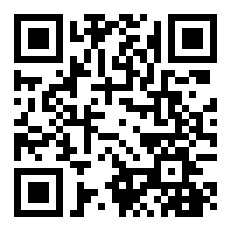

Record 0 Label: 1


In [ ]:
# Retrieving first QR code in dataset
record_0 = dataset[0]
print("Record 0 QR Image:")
display(record_0["image"])
print("Record 0 Label:", record_0["label"])

## Data Preprocessing:

In [ ]:
# Creating an 80/20 split for training and testing
dataset_split = dataset.train_test_split(
    test_size=0.2,
    seed=42
)

In [ ]:
# Defining the training and testing sets
train_dataset = dataset_split["train"]
test_dataset = dataset_split["test"]

In [ ]:
print("Samples in Training Set:", train_dataset.num_rows)
print("Samples in Testing Set:", test_dataset.num_rows)

Samples in Training Set: 8000
Samples in Testing Set: 2000


In [ ]:
def create_image_processor() -> AutoImageProcessor:
    """
    Loads an image processor that prerepares input features for vision models and post processing
    their outputs by transformations such as resizing, normalization, and conversion to PyTorch
    and Numpy tensors.

    Args:
        None:

    Returns:
        AutoImageProcessor: An image processor object
    """
    img_processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
    return img_processor

In [ ]:
# Loading the image processor
processor = create_image_processor()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [ ]:
def transforms(batch: Dataset) -> dict:
    """
    Transforms raw images to pixel values for vision transformer model.

    Args:
        batch: A batch from the dataset containing 'image' and 'label' keys

    Returns:
        dict: A dictionary with preprocessed 'pixel_values' and 'labels' keys
    """
    # Converting QR images to RGB format
    images = [x.convert("RGB") for x in batch["image"]]

    # Preprocessing the formatted images for the ViT model
    inputs = processor(images, return_tensors="pt")
    inputs["labels"] = batch["label"]

    return inputs

In [ ]:
def collate_fn(batch: Dataset) -> dict:
    """
    Takes the individual data samples (dictionaries) provided and combine sthem into a batched
    tensore for effiecient model training.

    Args:
        batch: A list of dictionaries containing 'pixel_values' and 'labels' keys

    Returns:
        dict: A dictionary with batched 'pixel_values' and 'labels' tensors
    """
    tensors = {"pixel_values": torch.stack([x["pixel_values"] for x in batch]),
               "labels": torch.tensor([x["labels"] for x in batch])}

    return tensors

In [ ]:
# Saving version of test set with no tranformation applied
untransformed_test_dataset = Dataset.from_dict(test_dataset.to_dict())

In [ ]:
# Applies image preprocessing on-the-fly when data is loaded
train_dataset.set_transform(transforms)
test_dataset.set_transform(transforms)

## Defining Evaluation Metrics:

In [ ]:
accuracy = evaluate.load("accuracy")

In [ ]:
def compute_metrics(eval_preds) -> dict:
    """
    Compute evaluation metrics for model predictions using the Hugging Face `evaluate` library.

    Args:
        eval_pred: The model's predictions

    Returns:
        dict: Restults of the evaluation metrics
    """
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=1)
    score = accuracy.compute(predictions=predictions, references=labels)
    return score

## Initializing ViT Model:

In [5]:
# Creating bi-directional label mappings for model configuration
id_to_label = {0: "Phishing", 1: "Legitimate"}
label_to_id = {"Phishing": 0, "Legitimate": 1}

In [6]:
# Model initialization
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels = 2,
    id2label = id_to_label,
    label2id = label_to_id,
    ignore_mismatched_sizes=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Freezing Non-Classifier Layers:

In [7]:
def freeze_model_layers(model: ViTForImageClassification, trainable_prefixes: list[str]=["classifier"]) -> str:
    """
    Freezes all model parameters except for specified trainable layers for transfer learning.

    Args:
        model: The ViT model to freeze layers in
        trainable_prefixes: A list of prefixes for layers to keep trainable (defaults to ['classifier'])

    Returns:
        str: A string displaying total parameters and trainable parameters
    """
    # Freeze all parameters except those whose names start with any of the specified prefixes
    for name, param in model.named_parameters():
        is_trainable = False
        for prefix in trainable_prefixes:
            if name.startswith(prefix):
                is_trainable = True
                break
        param.requires_grad = is_trainable

    # Count total and trainable parameters
    total_params = sum([p.numel() for p in model.parameters()])
    trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])

    return f"Total Params: {total_params:,} | Trainable Params: {trainable_params:,}"

In [8]:
freeze_model_layers(model, trainable_prefixes=["classifier", "vit.encoder.layer.11"])

'Total Params: 85,800,194 | Trainable Params: 7,089,410'

## Displaying Model Architecture:

In [ ]:
print("Model Configuration:")
print(model.config)
print(f"Model Name: {model.config.model_type}")
print(f"Hidden Size: {model.config.hidden_size}")
print(f"Number of Attention Heads: {model.config.num_attention_heads}")
print(f"Number of Hidden Layers: {model.config.num_hidden_layers}")
print(f"Image Size: {model.config.image_size}")
print(f"Patch Size: {model.config.patch_size}")
print(f"Number of Labels: {model.config.num_labels}")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model Configuration:
ViTConfig {
  "architectures": [
    "ViTForImageClassification"
  ],
  "attention_probs_dropout_prob": 0.0,
  "dtype": "float32",
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "id2label": {
    "0": "Phishing",
    "1": "Legitimate"
  },
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "Legitimate": 1,
    "Phishing": 0
  },
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "transformers_version": "4.57.2"
}

Model Name: vit
Hidden Size: 768
Number of Attention Heads: 12
Number of Hidden Layers: 12
Image Size: 224
Patch Size: 16
Number of Labels: 2
Total Parameters: 85,800,194


## Training/Fine-Tuning the ViT Model:

In [ ]:
# Defining training arguments
training_args = TrainingArguments(
    output_dir="./vit-base-qr-classifier",
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2, # Simulates a batch size of 32
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=500,
    num_train_epochs=15,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1, # gradually increase learning rate
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=True,
    report_to="none",
    optim="adamw_torch",
    load_best_model_at_end=True, # Load best model after training
    metric_for_best_model="eval_accuracy",  # Monitor validation accuracy
    greater_is_better=True, # Greater accuracy is better
)

In [ ]:
# Defining the training loop for the ViT model
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=processor, # 'tokenizer' will be depracated soon, use 'processing_class'
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)] # Early stop with patience of 3 epochs
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.619300,0.588094,0.711000
2,0.586100,0.576581,0.710500
3,0.574100,0.566850,0.712000
4,0.567700,0.562342,0.714500
5,0.564900,0.560635,0.713000


TrainOutput(global_step=2500, training_loss=0.5824196655273437, metrics={'train_runtime': 280.223, 'train_samples_per_second': 142.743, 'train_steps_per_second': 8.921, 'total_flos': 3.09967958458368e+18, 'train_loss': 0.5824196655273437, 'epoch': 5.0})

## Plotting Training History:

In [ ]:
def plot_training_metrics(trainer: Trainer) -> None:
    """
    Plots training loss and evaluation loss/accuracy over training steps/epochs.

    Args:
        trainer: The trained Trainer object containing log history

    Returns:
        None:
    """
    # Extracting log history from trainer
    log_history = trainer.state.log_history

    # Separating training and evaluation logs
    train_loss_logs = [log for log in log_history if "loss" in log and "eval_loss" not in log]
    eval_loss_logs = [log for log in log_history if "eval_loss" in log]
    eval_acc_logs = [log for log in log_history if "eval_accuracy" in log]

    # Creating subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plotting training loss
    if train_loss_logs:
        steps = [log["step"] for log in train_loss_logs]
        losses = [log["loss"] for log in train_loss_logs]
        ax1.plot(steps, losses, "b-", linewidth=2, label="Training Loss")

    # Plotting validation loss
    if eval_loss_logs:
        # Converting epochs to apporximate steps
        eval_steps = []
        eval_losses = []

        for log in eval_loss_logs:
            if "step" in log:
                eval_steps.append(log["step"])
            else:
                epoch = log["epoch"]
                # Calculating total steps for all epochs in train_loss_logs
                if train_loss_logs:
                    total_train_steps = max(log["step"] for log in train_loss_logs)
                    total_epochs = max(log["epoch"] for log in train_loss_logs if "epoch" in log)
                    steps_per_epoch = total_train_steps / total_epochs
                    estimated_step = int(epoch * steps_per_epoch)
                    eval_steps.append(estimated_step)
                else:
                    eval_steps.append(0) # Default to 0 or handle error if no training steps are logged

            eval_losses.append(log["eval_loss"])

        ax1.plot(eval_steps, eval_losses, "r-", marker="o", linewidth=2, markersize=6, label="Validation Loss")

    ax1.set_xlabel("Training Steps")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training vs. Validation Loss")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_ylim(0, 1)

    # Plotting validation accuracy
    if eval_acc_logs:
        epochs = [log["epoch"] for log in eval_acc_logs]
        accuracies = [log["eval_accuracy"] for log in eval_acc_logs]

        ax2.plot(epochs, accuracies, "g-", marker="o", linewidth=2, markersize=6, label="Validation Accuracy")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Accuracy")
        ax2.set_title("Validation Accuracy")
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        ax2.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    # Printting final metrics
    if train_loss_logs:
        print(f"\nFinal Training Loss: {train_loss_logs[-1]["loss"]:.4f}")
    if eval_loss_logs:
        print(f"Final Validation Loss: {eval_loss_logs[-1]["eval_loss"]:.4f}")
    if eval_acc_logs:
        print(f"Final Validation Accuracy: {eval_acc_logs[-1]["eval_accuracy"]:.4f}")

In [ ]:
plot_training_metrics(trainer)

## Model Evaluation and Predictions:

In [ ]:
trainer.evaluate(test_dataset)

In [ ]:
def create_confusion_matrix(trainer: Trainer, test_dataset: Dataset, id_to_label: dict) -> np.ndarray:
    """
    Generate and plot confusion matrix for the trained model.

    Args:
        trainer: The trained Trainer object
        test_dataset: Test dataset with transformations applied
        id_to_label: Dictionary mapping label IDs to label names

    Returns:
        np.ndarray: A NumPy array detailing the confusion matrix
    """
    # Getting predictions
    predictions_output = trainer.predict(test_dataset)
    predictions = np.argmax(predictions_output.predictions, axis=1)

    # Getting true labels
    true_labels = [sample["labels"] for sample in test_dataset]

    # Creating confusion matrix
    cm = confusion_matrix(true_labels, predictions)

    # Creating labels for the plot
    label_names = [id_to_label[i] for i in sorted(id_to_label.keys())]

    # Plotting confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()

    return cm

In [ ]:
conf_matrix = create_confusion_matrix(trainer, test_dataset, id_to_label)

In [ ]:
def create_classification_report(trainer: Trainer, test_dataset: Dataset, id_to_label: dict) -> None:
    """
    Generates and displays a classification report of the trained model.

    Args:
        trainer: The trained Trainer object
        test_dataset: Test dataset with transformations applied
        id_to_label: Dictionary mapping label IDs to label names

    Returns:
        None:
    """
    # Getting true labels
    true_labels = [sample["labels"] for sample in test_dataset]
    label_names = [id_to_label[i] for i in sorted(id_to_label.keys())]

    # Generating predictions
    predictions_output = trainer.predict(test_dataset)
    predictions = np.argmax(predictions_output.predictions, axis=1)

    # Displaying classification report
    print("Classification Report:\n")
    print(classification_report(true_labels, predictions, target_names=label_names))

    return

In [ ]:
create_classification_report(trainer, test_dataset, id_to_label)

In [ ]:
def show_predictions(original_data: Dataset, transformed_data: Dataset, rows: int=5, cols: int=5) -> None:
    """
    Displays the predicted label and true label for the specifed number of randomly chosen samples

    Args:
        original_data: The testing set without any transformation
        transformed_data: The testing set with transformation applies
        rows: Number of rows for the displayed grid
        cols: Number of columns for the display grid

    Returns:
        None:
    """
    n_samples = rows * cols

    # Getting indices of randomly picked samples
    random_indices = np.random.choice(len(original_data), n_samples, replace=False)

    # Selecting the original samples with corresponding indices
    samples_for_display = original_data.select(random_indices)

    # Selecting the same transformed samples
    samples_for_prediction = transformed_data.select(random_indices)

    # Generating predictions
    prediction_output = trainer.predict(samples_for_prediction)
    predictions = np.argmax(prediction_output.predictions, axis=1)

    fig = plt.figure(figsize=(rows*4, cols*4))

    for i in range(n_samples):
        # Reteiving image, true label, and predicted label
        current_sample = samples_for_display[i]
        img_path = current_sample["image"]["path"]
        img = Image.open(img_path)
        true_label_id = current_sample["label"]
        pred_label_id = predictions[i]

        # Mapping label ids to original text labels
        true_label_text = id_to_label[true_label_id]
        pred_label_text = id_to_label[pred_label_id]

        # Plotting current sample with true and predicted labels
        subplot_label = f"True Label: {true_label_text}\nPredicted Label: {pred_label_text}"
        fig.add_subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.title(subplot_label)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
show_predictions(untransformed_test_dataset, test_dataset)

## Model Explainabilty

In [10]:
def reshape_transform(tensor, height=14, width=14):
    """
    Reshapes the ViT output tensor to be compatible with Grad-CAM.
    Separates the class token, reshapes patch tokens to a grid, and transposes dimensions.
    """
    # Exclude the Class token (first token) and reshape the rest
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))

    # Transpose to (Batch, Channels, Height, Width)
    result = result.transpose(2, 3).transpose(1, 2)
    return result

def get_gradcam_visualization(image, model, processor):
    """
    Generates a Grad-CAM heatmap for a given image using the specified ViT model.
    """
    # Preprocess the image
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"]

    # Move input tensor to the same device as the model
    device = model.device
    pixel_values = pixel_values.to(device)

    # Define the target layer (LayerNorm is common for ViT)
    target_layers = [model.vit.layernorm]

    # Initialize GradCAM
    # reshape_transform is needed because ViT output is a sequence, not a spatial grid
    cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

    # Generate the heatmap
    # eigen_smooth=True helps reduce noise in the heatmap
    grayscale_cam = cam(input_tensor=pixel_values, targets=None, eigen_smooth=True)

    # Return the heatmap for the single image
    return grayscale_cam[0, :]

In [ ]:
def visualize_gradcam_samples(dataset, model, processor, id_to_label, num_samples=3):
    """
    Visualizes Grad-CAM explanations for random samples from the dataset.
    """
    # 1 & 2. Select random indices for each class
    phishing_indices = [i for i in range(len(dataset)) if dataset[i]['label'] == 0]
    legitimate_indices = [i for i in range(len(dataset)) if dataset[i]['label'] == 1]

    # Sample indices (ensure we don't request more than available)
    n_phishing = min(num_samples, len(phishing_indices))
    n_legitimate = min(num_samples, len(legitimate_indices))

    selected_phishing = np.random.choice(phishing_indices, n_phishing, replace=False)
    selected_legitimate = np.random.choice(legitimate_indices, n_legitimate, replace=False)

    # Combine and shuffle
    indices_to_plot = np.concatenate([selected_phishing, selected_legitimate])
    np.random.shuffle(indices_to_plot)

    # 3. Iterate through samples
    for idx in indices_to_plot:
        # a. Access image and label
        sample = dataset[int(idx)]
        image = sample['image'] # PIL Image
        true_label_id = sample['label']

        # b. Resize to 224x224
        image_resized = image.resize((224, 224))

        # c. Convert to numpy and normalize to [0, 1]
        img_np = np.array(image_resized)
        img_normalized = img_np.astype(np.float32) / 255.0

        # d. Generate Grad-CAM heatmap
        # Using the function defined in the previous cell
        heatmap = get_gradcam_visualization(image_resized, model, processor)

        # e. Create overlay
        visualization = show_cam_on_image(img_normalized, heatmap, use_rgb=True)

        # f. Determine model prediction
        inputs = processor(images=image_resized, return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            pred_label_id = torch.argmax(outputs.logits, dim=1).item()

        # g. Display
        true_label = id_to_label[true_label_id]
        pred_label = id_to_label[pred_label_id]

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(image_resized)
        axes[0].set_title(f"Original Image\nTrue: {true_label}")
        axes[0].axis('off')

        axes[1].imshow(visualization)
        axes[1].set_title(f"Grad-CAM Overlay\nPred: {pred_label}")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

# Execute the visualization
visualize_gradcam_samples(untransformed_test_dataset, model, processor, id_to_label, num_samples=3)